# Week11: A Guide to Fuzzy Logic with Scikit-Fuzzy - Part 1 : Fuzzy Logic Basics and Control Systems

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. It provides a detailed introduction to building fuzzy logic systems using the `scikit-fuzzy` (skfuzzy) Python library.

In This notebook, we will cover the following topics:
- Understanding the basic concepts of fuzzy logic and its applications.
- Exploring the concept of fuzzy sets and how to define membership functions.
- Learning how to create fuzzy rules and perform fuzzy inference.
- Building a simple fuzzy control system using `scikit-fuzzy`.
- Demonstrating the application of fuzzy logic in real-world scenarios.

## 1. Installation and Setup

Ensure you have the necessary libraries installed. If not, you can install them using pip:

In [ ]:
!pip install -U scikit-fuzzy

In [21]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## 2. The Water Tank Level Controller Problem

We want to design a fuzzy logic controller to manage the water level in a tank. The system has:

* **Inputs (Antecedents):**
    1.  `level`: The current water level in the tank.
    2.  `rate`: The rate of change of the water level. A negative rate means the level is falling, positive means it's rising.
* **Output (Consequent):**
    1.  `valve`: The opening of the inlet valve (e.g., 0% to 100%). 0% means fully closed, 100% means fully open.

**Objective:** Maintain the water level at a desired 'optimal' state by adjusting the valve.

## 3. Defining Fuzzy Variables (Antecedents and Consequents)

Antecedents and Consequents represent the input and output variables of our fuzzy system. We define them with a universe of discourse (the range of possible values) and a name.

In [2]:
# Define the universe of discourse for each variable
# Initial ranges
level_universe = np.arange(0, 101, 1)  # Percentage 0-100
rate_universe = np.arange(-10, 11, 1) # Percentage change -10 to +10
valve_universe = np.arange(0, 101, 1)  # Percentage 0-100

# Create fuzzy variables
level = ctrl.Antecedent(level_universe, 'level')
rate = ctrl.Antecedent(rate_universe, 'rate')
valve = ctrl.Consequent(valve_universe, 'valve')

### 3.1. Viewing Variable Definitions

We can inspect the created variables:

In [25]:
print(level)
print(rate)
print(valve)

# The .universe attribute holds the range
print(f"\nLevel Universe: {level.universe}")
print(f"\nValve Default Defuzzify Method: {valve.defuzzify_method}")


Antecedent: level
Antecedent: rate
Consequent: valve

Level Universe: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]

Valve Default Defuzzify Method: centroid


## 3. Membership Functions (MFs): Shaping Fuzzy Sets

Membership functions define how each point in the input or output space is mapped to a membership value (or degree of membership) between 0 and 1 in a fuzzy set. `skfuzzy` offers various types.

### 3.1. Automatic Membership Function Generation (`automf`)

`skfuzzy` provides a convenient `automf` method to quickly populate a variable with a specified number of evenly distributed MFs. You can choose from 3, 5, or 7 MFs. The names are typically 'poor', 'mediocre', 'average', 'decent', 'good', etc., or based on number.

/opt/homebrew/lib/python3.9/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


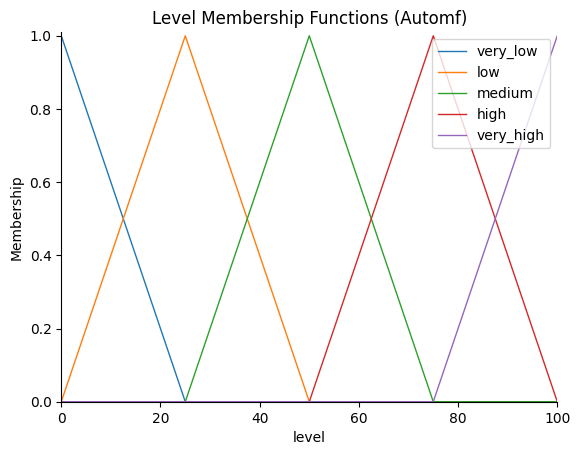

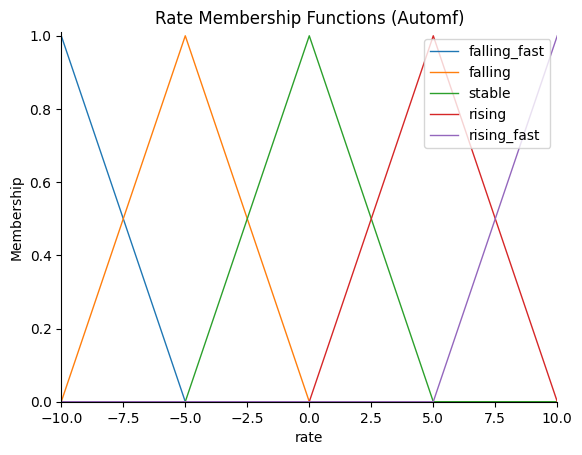

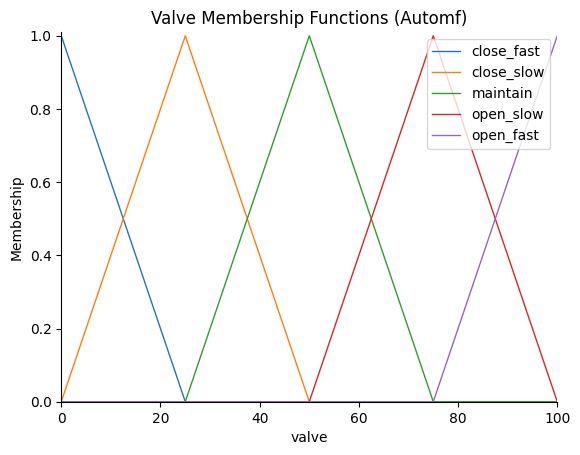

In [ ]:
# Using automf for a quick setup
level.automf(number=5, variable_type='quant', names=['very_low', 'low', 'medium', 'high', 'very_high'])
rate.automf(number=5, variable_type='quant', names=['falling_fast', 'falling', 'stable', 'rising', 'rising_fast'])

# For the output, we often want more control
valve.automf(number=5, variable_type='quant', names=['close_fast', 'close_slow', 'maintain', 'open_slow', 'open_fast'])

# View the automatically generated MFs
level.view()
plt.title('Level Membership Functions (Automf)')
plt.legend(loc='upper right') 
plt.show()

rate.view()
plt.title('Rate Membership Functions (Automf)')
plt.legend(loc='upper right') 
plt.show()

valve.view()
plt.title('Valve Membership Functions (Automf)')
plt.legend(loc='upper right') 
plt.show()

While `automf` is quick, for fine-tuned control systems, manual definition of MFs is usually preferred.

### 3.2. Manually Defining Membership Functions

Let's redefine the MFs manually for more precision. We'll use common types: triangular (`trimf`), trapezoidal (`trapmf`), and Gaussian (`gaussmf`).

**Syntax:**
* `fuzz.trimf(universe, [a, b, c])`: Triangle with feet at `a` and `c`, and peak at `b`.
* `fuzz.trapmf(universe, [a, b, c, d])`: Trapezoid with feet at `a` and `d`, and shoulders at `b` and `c`.
* `fuzz.gaussmf(universe, mean, sigma)`: Gaussian curve centered at `mean` with spread `sigma`.
* `fuzz.gbellmf(universe, a, b, c)`: Generalized bell-shaped function. `a` is width, `b` is slope, `c` is center.
* `fuzz.sigmf(universe, center, slope)`: Sigmoidal function. Can be used for transitions.

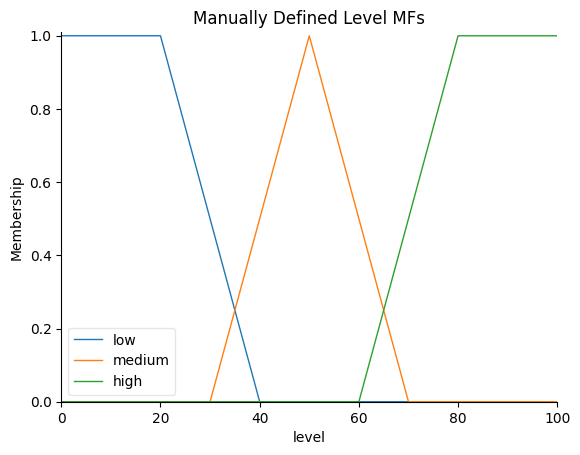

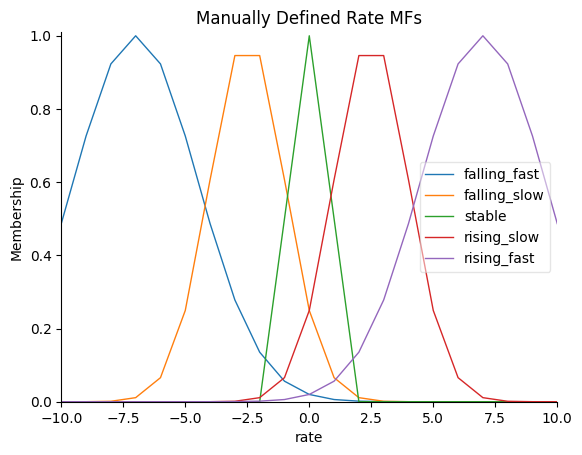

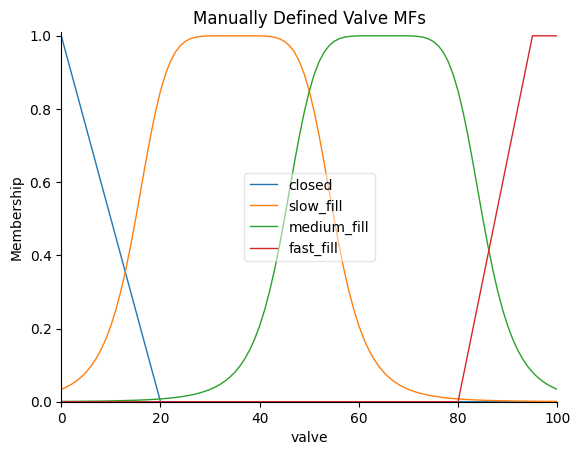

In [27]:
# Clear any existing MFs if re-running this cell
level.terms.clear()
rate.terms.clear()
valve.terms.clear()

# --- Level Membership Functions (0-100) ---
# Using a mix of trapmf for edges and trimf for central regions
level['low'] = fuzz.trapmf(level.universe, [0, 0, 20, 40])
level['medium'] = fuzz.trimf(level.universe, [30, 50, 70])
level['high'] = fuzz.trapmf(level.universe, [60, 80, 100, 100])

# --- Rate Membership Functions (-10 to +10) ---
# Using gaussmf for smoother transitions
rate['falling_fast'] = fuzz.gaussmf(rate.universe, -7, 2.5) # mean, sigma
rate['falling_slow'] = fuzz.gaussmf(rate.universe, -2.5, 1.5)
rate['stable'] = fuzz.trimf(rate.universe, [-2, 0, 2]) # A narrow stable region
rate['rising_slow'] = fuzz.gaussmf(rate.universe, 2.5, 1.5)
rate['rising_fast'] = fuzz.gaussmf(rate.universe, 7, 2.5)

# --- Valve Membership Functions (0-100) ---
# Using a mix
valve['closed'] = fuzz.trimf(valve.universe, [0, 0, 20]) # Fully closed to slightly open
valve['slow_fill'] = fuzz.gbellmf(valve.universe, 20, 3, 35) # width, slope, center
valve['medium_fill'] = fuzz.gbellmf(valve.universe, 20, 3, 65)
valve['fast_fill'] = fuzz.trapmf(valve.universe, [80, 95, 100, 100]) # Towards fully open

# View the manually defined MFs
level.view()
plt.title('Manually Defined Level MFs')
rate.view()
plt.title('Manually Defined Rate MFs')
valve.view()
plt.title('Manually Defined Valve MFs')
plt.show()

### 4.3. Modifying Membership Function Parameters

The shape and position of MFs are crucial for system performance. Let's see how to modify them and visualize the impact.

Suppose we want the 'medium' level to be a wider band, say from 25 to 75, peaking at 50.

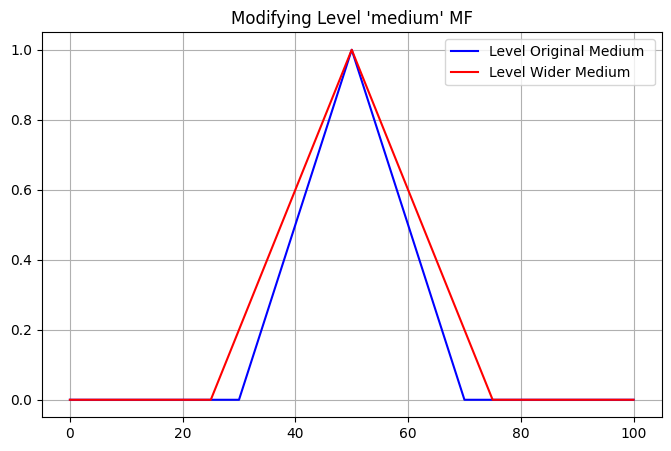

In [44]:
# Original 'medium' level MF was: fuzz.trimf(level.universe, [30, 50, 70])

# Modify the 'medium' level MF
level['medium_wider'] = fuzz.trimf(level.universe, [25, 50, 75])

# Plot to compare (original 'medium' vs 'medium_wider')
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(level.universe, level['medium'].mf, 'b', linewidth=1.5, label='Level Original Medium ')
ax.plot(level.universe, level['medium_wider'].mf, 'r', linewidth=1.5, label='Level Wider Medium')
ax.set_title('Modifying Level \'medium\' MF')
ax.legend()
ax.grid(True)
plt.show()

# For actual use, you would replace the old MF:
level['medium'] = fuzz.trimf(level.universe, [25, 50, 75])
# And then remove the temporary one:
del level.terms['medium_wider'] 


Let's make the 'stable' rate (currently `trimf([-2, 0, 2])`) a bit more sensitive, using a Gaussian centered at 0 with a smaller sigma (e.g., sigma=0.5).

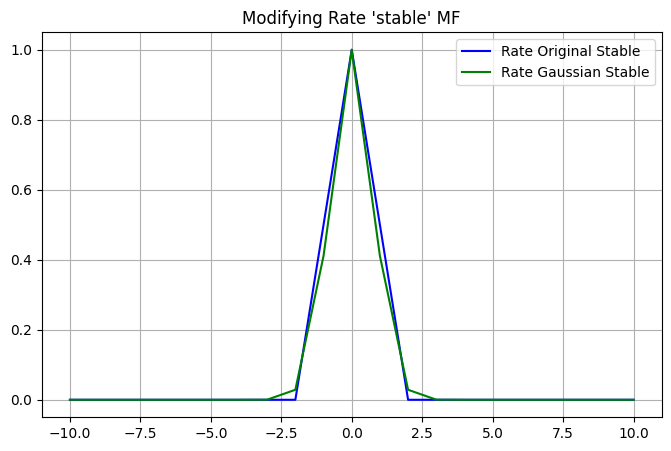

In [45]:
# Original 'stable' rate MF: fuzz.trimf(rate.universe, [-2, 0, 2])
rate_stable_original_mf = rate['stable'].mf # Save for plotting

# Modify the 'stable' rate MF to be Gaussian
rate['stable_gaussian'] = fuzz.gaussmf(rate.universe, 0, 0.75) # mean=0, sigma=0.75

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rate.universe, rate_stable_original_mf, 'b', linewidth=1.5, label='Rate Original Stable')
ax.plot(rate.universe, rate['stable_gaussian'].mf, 'g', linewidth=1.5, label='Rate Gaussian Stable')
ax.set_title('Modifying Rate \'stable\' MF')
ax.legend()
ax.grid(True)
plt.show()

# Again, to make this permanent:
rate['stable'] = fuzz.gaussmf(rate.universe, 0, 0.75)
del rate.terms['stable_gaussian']


## 4. Fuzzification (Conceptual Overview)

Fuzzification is the process of taking a crisp (numerical) input value and determining the degree to which it belongs to each of the fuzzy sets defined by the MFs.

For example, if `level` is 35, we would find its membership degree in `level['low']`, `level['medium']`, and `level['high']`.

`skfuzzy.control` handles this implicitly when you provide inputs to a `ControlSystemSimulation`. However, we can manually check membership values using `fuzz.interp_membership`.

In [10]:
crisp_level_input = 35
crisp_rate_input = -1

# Calculate membership degrees for the crisp_level_input
level_is_low = fuzz.interp_membership(level.universe, level['low'].mf, crisp_level_input)
level_is_medium = fuzz.interp_membership(level.universe, level['medium'].mf, crisp_level_input)
level_is_high = fuzz.interp_membership(level.universe, level['high'].mf, crisp_level_input)

# Calculate membership degrees for the crisp_rate_input
rate_is_falling_fast = fuzz.interp_membership(rate.universe, rate['falling_fast'].mf, crisp_rate_input)
rate_is_falling_slow = fuzz.interp_membership(rate.universe, rate['falling_slow'].mf, crisp_rate_input)
rate_is_stable = fuzz.interp_membership(rate.universe, rate['stable'].mf, crisp_rate_input)
rate_is_rising_slow = fuzz.interp_membership(rate.universe, rate['rising_slow'].mf, crisp_rate_input)
rate_is_rising_fast = fuzz.interp_membership(rate.universe, rate['rising_fast'].mf, crisp_rate_input)

print(f"Crisp Level Input: {crisp_level_input}")
print(f"  Membership in 'low': {level_is_low:.4f}")
print(f"  Membership in 'medium': {level_is_medium:.4f}")
print(f"  Membership in 'high': {level_is_high:.4f}")

print(f"\nCrisp Rate Input: {crisp_rate_input}")
print(f"  Membership in 'falling_fast': {rate_is_falling_fast:.4f}")
print(f"  Membership in 'falling_slow': {rate_is_falling_slow:.4f}")
print(f"  Membership in 'stable': {rate_is_stable:.4f}")
print(f"  Membership in 'rising_slow': {rate_is_rising_slow:.4f}")
print(f"  Membership in 'rising_fast': {rate_is_rising_fast:.4f}")

Crisp Level Input: 35
  Membership in 'low': 0.2500
  Membership in 'medium': 0.2500
  Membership in 'high': 0.0000

Crisp Rate Input: -1
  Membership in 'falling_fast': 0.0561
  Membership in 'falling_slow': 0.6065
  Membership in 'stable': 0.5000
  Membership in 'rising_slow': 0.0657
  Membership in 'rising_fast': 0.0060


## 5. Defining Fuzzy Rules

Rules are the core of the fuzzy logic system, defining how the inputs relate to the outputs in an IF-THEN format.

* `&` is used for the logical AND operator (T-norm, typically `np.fmin`).
* `|` is used for the logical OR operator (T-conorm or S-norm, typically `np.fmax`).

In [47]:
# Rule 1: IF level is low AND rate is falling_fast THEN valve is fast_fill.
rule1 = ctrl.Rule(level['low'] & rate['falling_fast'], valve['fast_fill'])

# Rule 2: IF level is low AND rate is falling_slow THEN valve is fast_fill.
rule2 = ctrl.Rule(level['low'] & rate['falling_slow'], valve['fast_fill'])

# Rule 3: IF level is low AND rate is stable THEN valve is medium_fill.
rule3 = ctrl.Rule(level['low'] & rate['stable'], valve['medium_fill'])

# Rule 4: IF level is low AND rate is rising_slow THEN valve is medium_fill.
rule4 = ctrl.Rule(level['low'] & rate['rising_slow'], valve['medium_fill'])

# Rule 5: IF level is medium AND rate is falling_fast THEN valve is medium_fill.
rule5 = ctrl.Rule(level['medium'] & rate['falling_fast'], valve['medium_fill'])

# Rule 6: IF level is medium AND rate is falling_slow THEN valve is slow_fill.
rule6 = ctrl.Rule(level['medium'] & rate['falling_slow'], valve['slow_fill'])

# Rule 7: IF level is medium AND rate is stable THEN valve is slow_fill.
rule7 = ctrl.Rule(level['medium'] & rate['stable'], valve['slow_fill'])

# Rule 8: IF level is medium AND rate is rising_slow THEN valve is closed.
rule8 = ctrl.Rule(level['medium'] & rate['rising_slow'], valve['closed'])

# Rule 9: IF level is high AND rate is falling_slow THEN valve is closed. 
rule9 = ctrl.Rule(level['high'] & rate['falling_slow'], valve['closed'])

# Rule 10: IF level is high AND rate is stable THEN valve is closed.
rule10 = ctrl.Rule(level['high'] & rate['stable'], valve['closed'])

# Rule 11: IF level is high AND (rate is rising_slow OR rate is rising_fast) THEN valve is closed.
rule11 = ctrl.Rule(level['high'] & (rate['rising_slow'] | rate['rising_fast']), valve['closed'])

# Rule 12: IF rate is rising_fast THEN valve is closed
rule12 = ctrl.Rule(rate['rising_fast'], valve['closed'])

## 6. Defuzzification Methods: From Fuzzy to Crisp Output

Defuzzification converts the aggregated fuzzy output set (which is still a fuzzy set) into a single crisp numerical value that can be used to control the system.

`skfuzzy` supports several methods, set via the `defuzzify_method` attribute of a `Consequent` object (or specified during its creation). The default is 'centroid'.

Common methods:
* `'centroid'`: Calculates the Center of Gravity of the aggregated fuzzy set. Most common.
* `'bisector'`: Finds the point where the area of the fuzzy set is divided into two equal halves.
* `'mom'` (Mean of Maximum): Average of the values with the highest membership degree.
* `'som'` (Smallest of Maximum): Smallest value with the highest membership degree.
* `'lom'` (Largest of Maximum): Largest value with the highest membership degree.

### 6.1. Setting and Changing the Defuzzification Method

You can set the method when creating the `Consequent` or change it later. The default for `valve` is 'centroid'.

In [48]:
print(f"Initial defuzzify method for 'valve': {valve.defuzzify_method}")

# Change the defuzzification method for the 'valve' Consequent
valve.defuzzify_method = 'mom' # Mean of Maximum
print(f"Changed defuzzify method for 'valve': {valve.defuzzify_method}")

Initial defuzzify method for 'valve': mom
Changed defuzzify method for 'valve': mom


## 7. Building and Simulating the Control System

Now we combine the rules into a control system and create a simulation environment to test it.

In [49]:
# Collect all rules
tank_rules = [
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12
]

# Create the control system
tank_ctrl_sys = ctrl.ControlSystem(tank_rules)

# Create a simulation instance
tank_simulation = ctrl.ControlSystemSimulation(tank_ctrl_sys)

### 7.1. Running a Simulation with Specific Inputs

Scenario 1: Level=25, Rate=-3  => Valve Opening: 95.53%


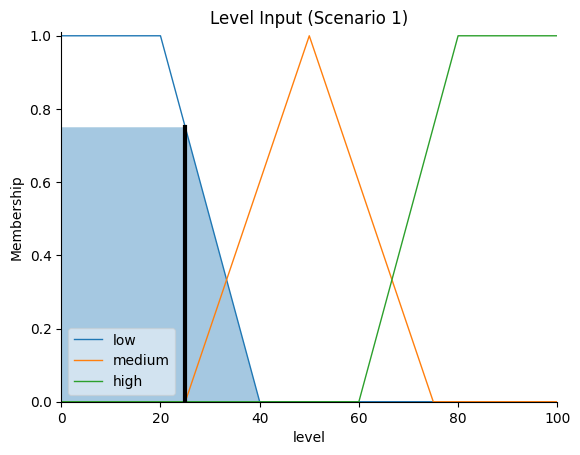

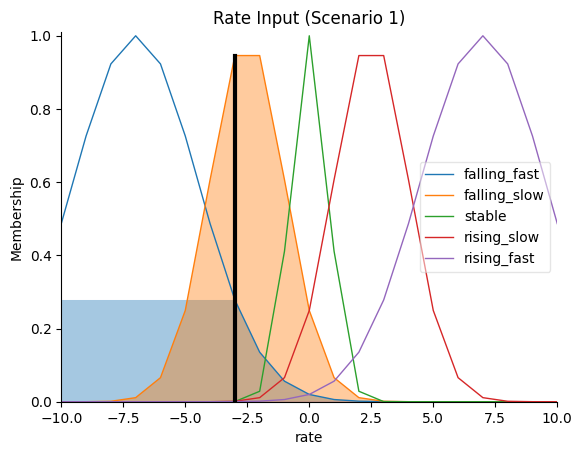

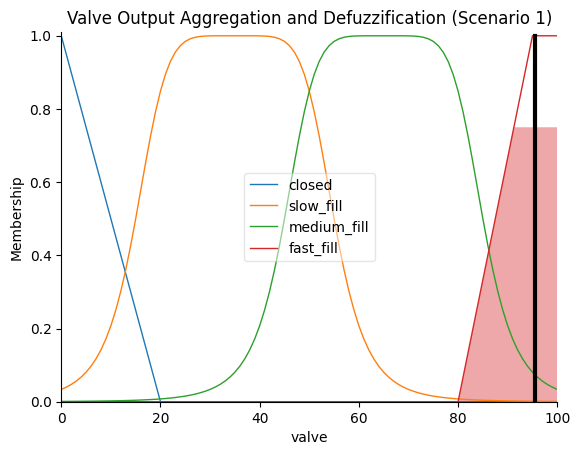

In [50]:
# Scenario 1: Level is low (25%) and falling slowly (-3 units)
tank_simulation.input['level'] = 25
tank_simulation.input['rate'] = -3

# Compute the output
tank_simulation.compute()
output_valve_setting = tank_simulation.output['valve']

print(f"Scenario 1: Level=25, Rate=-3  => Valve Opening: {output_valve_setting:.2f}%")

# Visualize the output for this specific scenario
level.view(sim=tank_simulation)
plt.title('Level Input (Scenario 1)')
plt.show()
rate.view(sim=tank_simulation)
plt.title('Rate Input (Scenario 1)')
plt.show()

valve.view(sim=tank_simulation)
plt.title('Valve Output Aggregation and Defuzzification (Scenario 1)')
plt.show()

Scenario 2: Level=55, Rate=2  => Valve Opening: 2.00%


/opt/homebrew/lib/python3.9/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


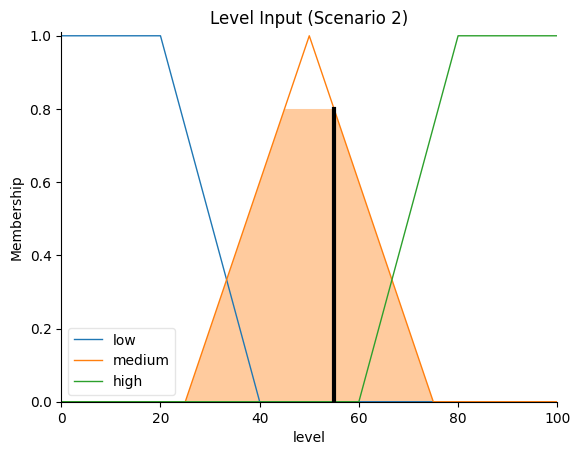

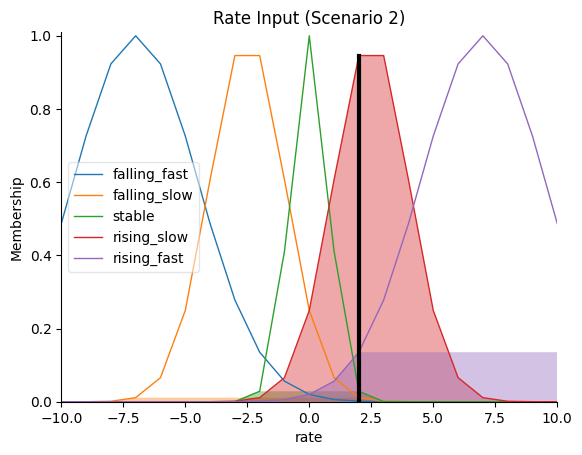

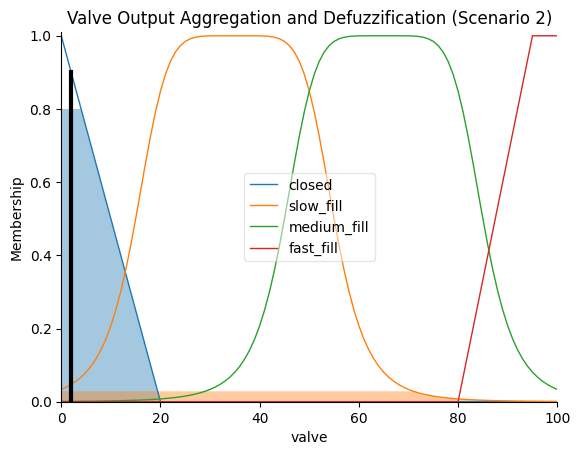

In [51]:
# Scenario 2: Level is medium (55%) and rising slowly (2)
tank_simulation.input['level'] = 55
tank_simulation.input['rate'] = 2
tank_simulation.compute()
output_valve_setting = tank_simulation.output['valve']
print(f"Scenario 2: Level=55, Rate=2  => Valve Opening: {output_valve_setting:.2f}%")

# Visualize the output for this specific scenario
level.view(sim=tank_simulation)
plt.title('Level Input (Scenario 2)')
plt.show()
rate.view(sim=tank_simulation)
plt.title('Rate Input (Scenario 2)')
plt.show()

valve.view(sim=tank_simulation)
plt.title('Valve Output Aggregation and Defuzzification (Scenario 2)')
plt.show()

Scenario 3: Level=85, Rate=0  => Valve Opening: 0.00%


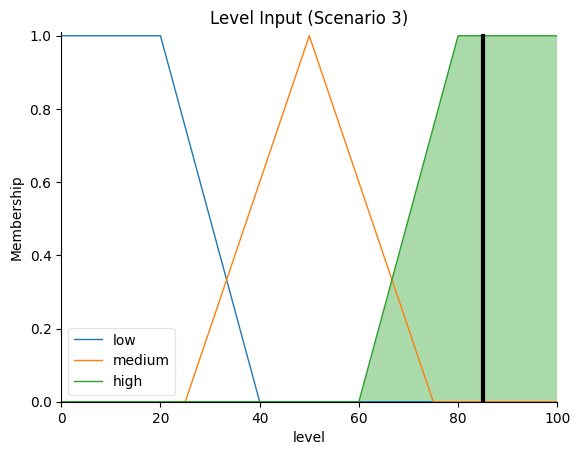

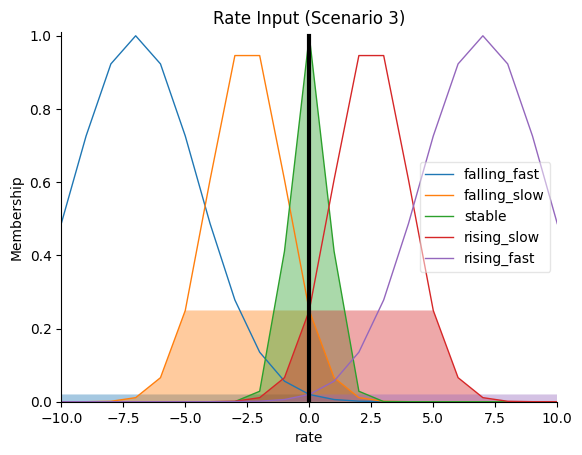

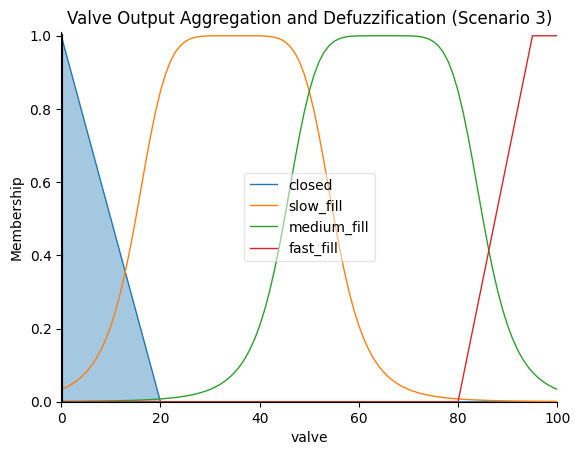

In [52]:
# Scenario 3: Level is high (85%) and stable (0)
tank_simulation.input['level'] = 85
tank_simulation.input['rate'] = 0
tank_simulation.compute()
output_valve_setting = tank_simulation.output['valve']
print(f"Scenario 3: Level=85, Rate=0  => Valve Opening: {output_valve_setting:.2f}%")

# Visualize the output for this specific scenario
level.view(sim=tank_simulation)
plt.title('Level Input (Scenario 3)')
plt.show()
rate.view(sim=tank_simulation)
plt.title('Rate Input (Scenario 3)')
plt.show()

valve.view(sim=tank_simulation)
plt.title('Valve Output Aggregation and Defuzzification (Scenario 3)')
plt.show()

### 7.2. Visualizing the Control Surface

If you have two inputs and one output, you can visualize the entire control surface. This shows the output value for every combination of the two input values. This is computationally intensive as it runs many simulations.

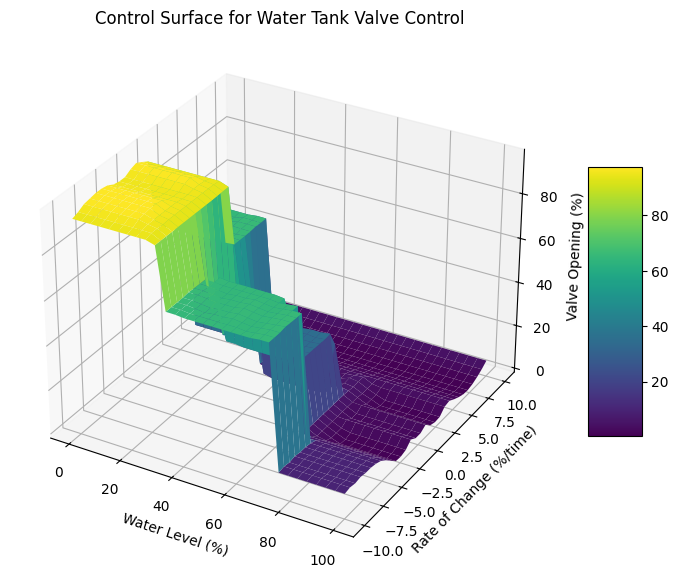

In [57]:
# Define sample points for inputs
sampled_level = np.linspace(level.universe.min(), level.universe.max(), 30)
sampled_rate = np.linspace(rate.universe.min(), rate.universe.max(), 30)

# Create a 2D grid for plotting
X, Y = np.meshgrid(sampled_level, sampled_rate)
Z = np.zeros_like(X)

# Ensure valve is using centroid for this standard plot
tank_ctrl_sys_for_surface = ctrl.ControlSystem(tank_rules)
tank_sim_for_surface = ctrl.ControlSystemSimulation(tank_ctrl_sys_for_surface)

# Loop through the grid to compute output for each combination
for i in range(sampled_level.shape[0]):
    for j in range(sampled_rate.shape[0]):
        tank_sim_for_surface.input['level'] = X[i, j]
        tank_sim_for_surface.input['rate'] = Y[i, j]
        try:
            tank_sim_for_surface.compute()
            Z[i, j] = tank_sim_for_surface.output['valve']
        except Exception as e:
            # Handle cases where rules might not cover all inputs or other issues
            Z[i, j] = 0

# Plot the control surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

ax.set_xlabel('Water Level (%)')
ax.set_ylabel('Rate of Change (%/time)')
ax.set_zlabel('Valve Opening (%)')
ax.set_title('Control Surface for Water Tank Valve Control')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()